In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import seaborn as sns

In [6]:
df = pd.read_csv("../data/synthetic_topic_articles_v4.csv")

In [9]:
df.head()

,article_id,title,article_text,topic,subtopic,routing_label,publication_type,article_length,difficulty,source_type,primary_topic_rule,word_count
0,V4-0184,What Recent Returns Management Announcements R...,Recent announcements around returns management...,retail_ecommerce,returns management,other,market_commentary,medium,easy,synthetic_v4,label reflects the article's primary subject,122
1,V4-0126,Inside the Architecture of Camera Systems,Camera Systems combines several technical and ...,consumer_electronics,camera systems,other,technology_explainer,short,medium,synthetic_v4,label reflects the article's primary subject,116
2,V4-0042,Operators Rethink the Economics of Ai Infrastr...,A growing number of operators are reconsiderin...,cloud_computing,AI infrastructure,target,trade_publication,medium,hard,synthetic_v4,label reflects the article's primary subject,211
3,V4-0117,Operators Rethink the Economics of Camera Systems,The market for camera systems is moving from e...,consumer_electronics,camera systems,other,trade_publication,long,easy,synthetic_v4,label reflects the article's primary subject,237
4,V4-0100,The Market Debate Around Low-Code Applications...,The debate over low-code applications has shif...,enterprise_software,low-code applications,other,market_commentary,long,easy,synthetic_v4,label reflects the article's primary subject,228


In [16]:
df.nunique()

article_id            200
title                 191
article_text          200
topic                  10
subtopic               75
routing_label           2
publication_type        6
article_length          3
difficulty              3
source_type             1
primary_topic_rule      1
word_count            126
dtype: int64

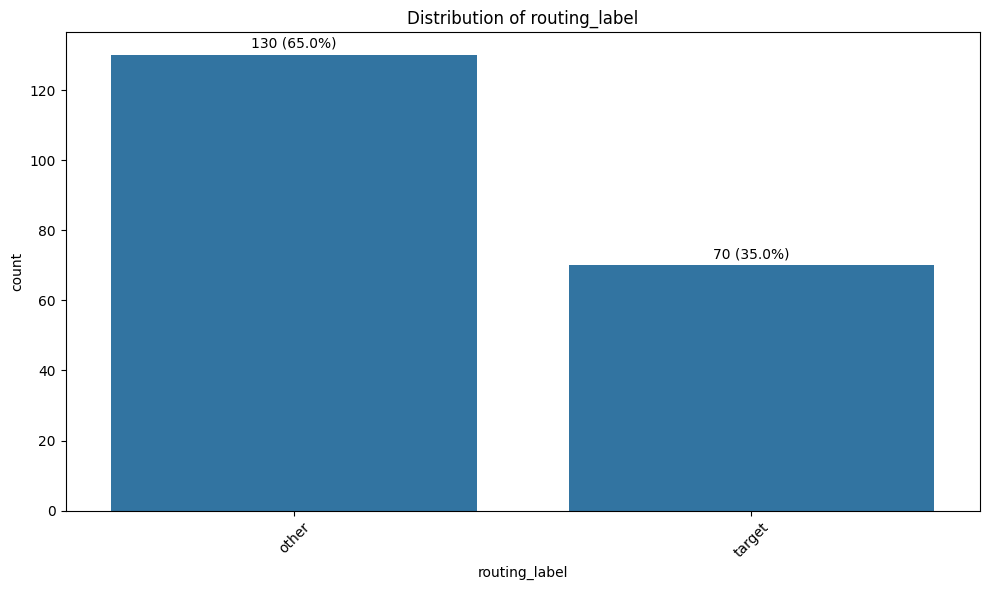

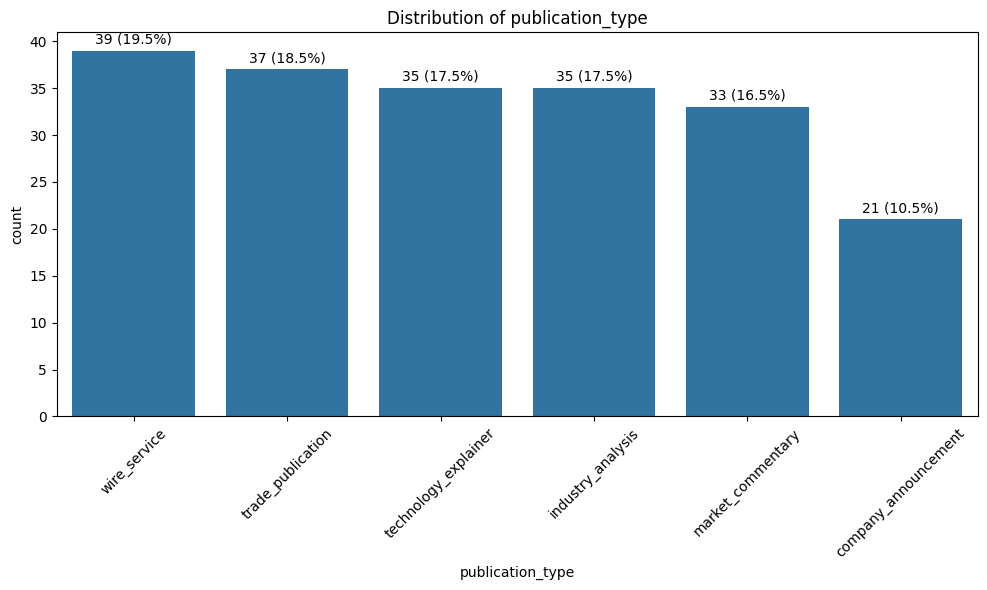

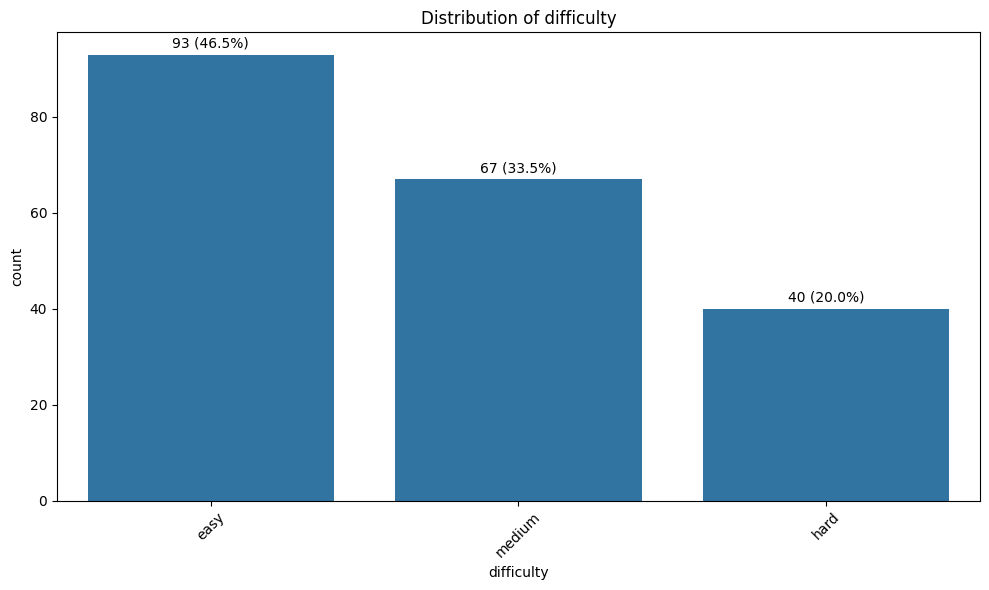

In [92]:
for col in [
    "routing_label",
    "publication_type",
    "difficulty",
]:
    plt.figure(figsize=(10, 6))
    counts = df[col].value_counts()
    total = counts.sum()
    ax = sns.barplot(x=counts.index, y=counts.values)
    labels = [f"{int(v)} ({100 * v / total:.1f}%)" for v in counts.values]
    ax.bar_label(ax.containers[0], labels=labels, padding=3)
    ax.set_xlabel(col)
    ax.set_ylabel("count")
    plt.xticks(rotation=45)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()




In [40]:
df.groupby("topic")["subtopic"].nunique()

topic
cloud_computing             7
consumer_electronics        8
cybersecurity               8
energy                      7
enterprise_software         8
financial_services          8
healthcare                  6
retail_ecommerce            8
telecommunications          8
transportation_logistics    7
Name: subtopic, dtype: int64

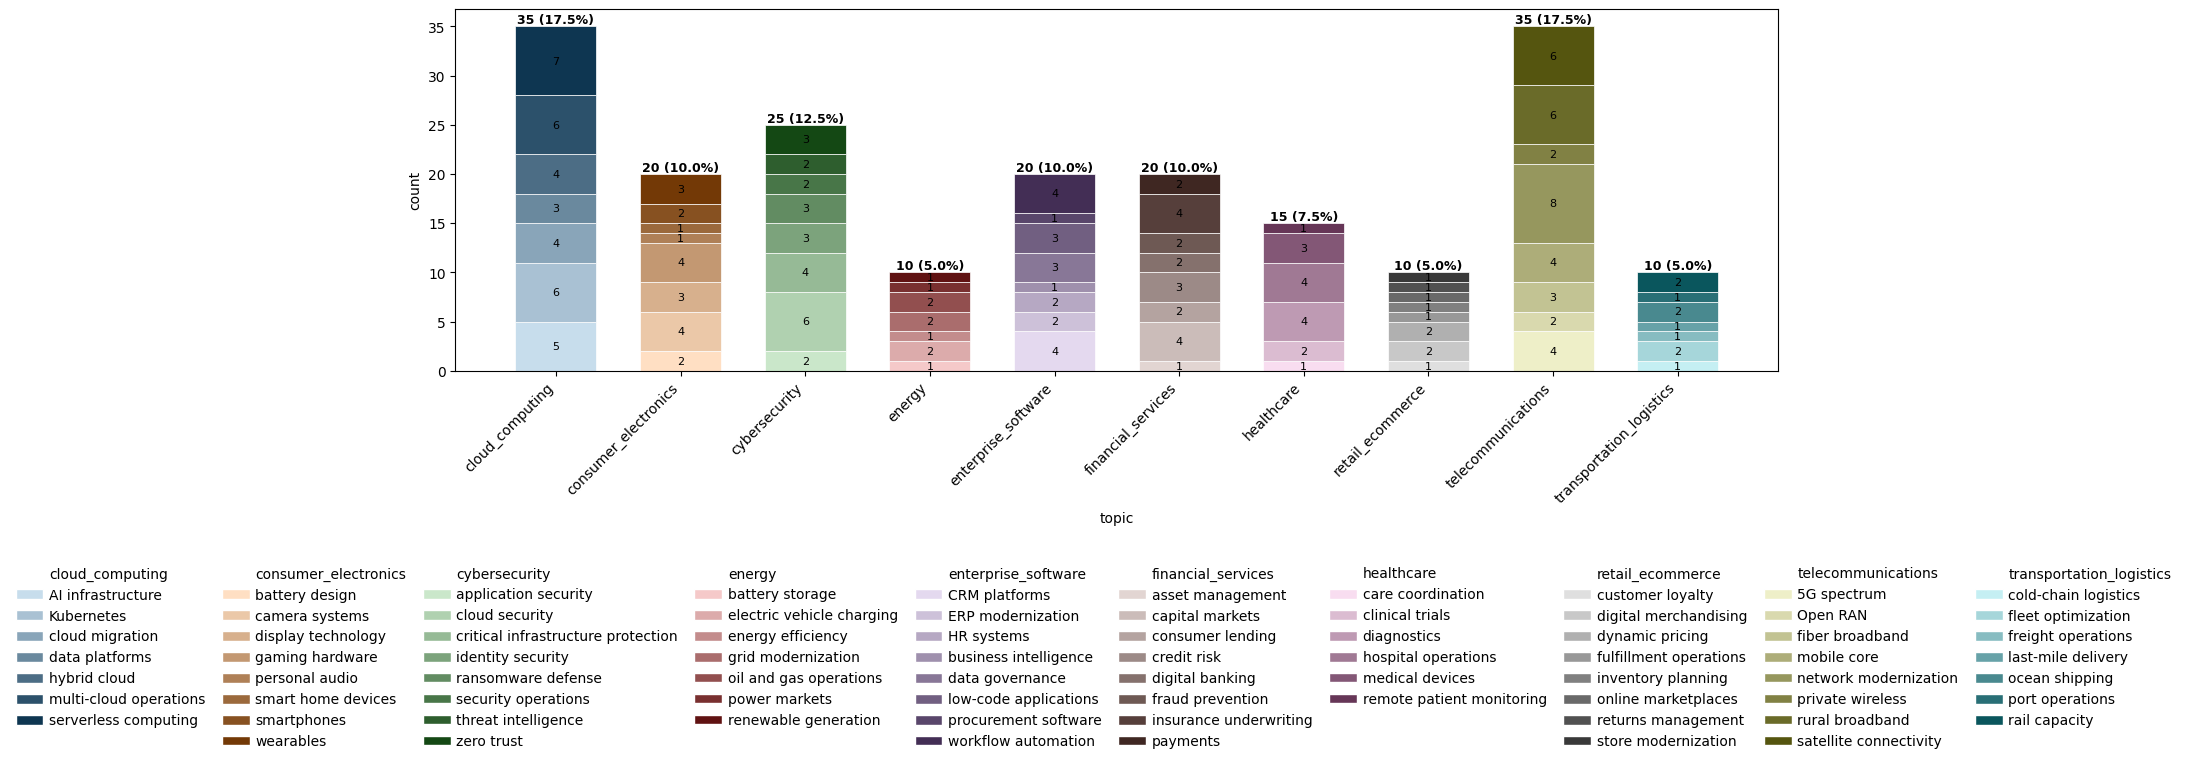

In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

ct = pd.crosstab(df["topic"], df["subtopic"])
topics = ct.index.tolist()
n_topics = len(topics)

# one base hue per topic
base_rgbs = [
    mcolors.to_rgb(c)
    for c in plt.cm.tab10(np.linspace(0, 1, max(n_topics, 1)))
]


def topic_shades(base_rgb, n):
    """Different shades of the same topic color (light → dark)."""
    if n == 1:
        return [base_rgb]
    light = tuple(0.75 + 0.25 * c for c in base_rgb)
    dark = tuple(0.45 * c for c in base_rgb)
    cmap = mcolors.LinearSegmentedColormap.from_list("shade", [light, dark])
    return [cmap(i / (n - 1)) for i in range(n)]


fig, ax = plt.subplots(figsize=(14, 7))
width = 0.65
legend_by_topic = {t: [] for t in topics}

for i, topic in enumerate(topics):
    row = ct.loc[topic]
    row = row[row > 0]  # skip empty subtopics
    subtopics = row.index.tolist()
    values = row.values.astype(float)
    shades = topic_shades(base_rgbs[i], len(subtopics))

    bottom = 0.0
    for sub, val, color in zip(subtopics, values, shades):
        bars = ax.bar(
            i, val, width,
            bottom=bottom,
            color=color,
            edgecolor="white",
            linewidth=0.5,
        )
        ax.bar_label(bars, labels=[int(val)], label_type="center", fontsize=8)
        legend_by_topic[topic].append(
            Patch(facecolor=color, edgecolor="white", label=sub)
        )
        bottom += val

# total count + percentage on top of each bar
totals = ct.sum(axis=1)
grand_total = totals.sum()
for i, topic in enumerate(topics):
    total = int(totals.loc[topic])
    pct = 100 * total / grand_total
    ax.text(
        i,
        total,
        f"{total} ({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )

ax.set_xticks(range(n_topics))
ax.set_xticklabels(topics, rotation=45, ha="right")
ax.set_xlabel("topic")
ax.set_ylabel("count")

# legend: one column per topic (matplotlib fills column-major)
max_subs = max(len(v) for v in legend_by_topic.values())
handles, labels = [], []

for topic in topics:
    # column header
    handles.append(Patch(facecolor="none", edgecolor="none"))
    labels.append(topic)

    # subtopics under this topic
    items = legend_by_topic[topic]
    for item in items:
        handles.append(item)
        labels.append(item.get_label())

    # pad so columns align
    for _ in range(max_subs - len(items)):
        handles.append(Patch(facecolor="none", edgecolor="none"))
        labels.append("")

fig.legend(
    handles,
    labels,
    ncol=n_topics,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.2),
    bbox_transform=fig.transFigure,
    frameon=False,
    columnspacing=1.2,
    handletextpad=0.4,
)

fig.tight_layout(rect=[0, 0.22, 1, 1])
plt.show()

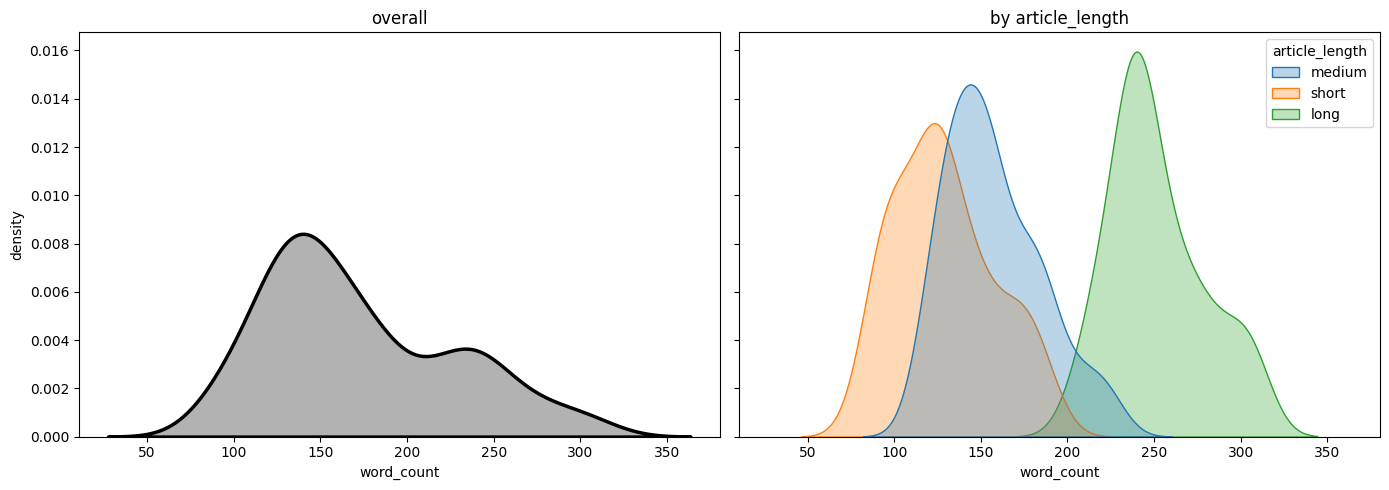

In [114]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

# overall
sns.kdeplot(
    data=df,
    x="word_count",
    color="black",
    linewidth=2.5,
    fill=True,
    alpha=0.3,
    ax=axes[0],
)
axes[0].set_title("overall")
axes[0].set_xlabel("word_count")
axes[0].set_ylabel("density")

# by article_length
sns.kdeplot(
    data=df,
    x="word_count",
    hue="article_length",
    common_norm=False,
    fill=True,
    alpha=0.3,
    ax=axes[1],
)
axes[1].set_title("by article_length")
axes[1].set_xlabel("word_count")
axes[1].set_ylabel("density")

plt.tight_layout()
plt.show()

In [11]:
print(df["article_text"][0])

Recent announcements around returns management reveal a market that is expanding but not yet standardized.

Workforce constraints are another concern. Companies need technical specialists as well as operational employees who understand how the new capability affects day-to-day decisions.

Executives are also paying attention to supplier concentration and contract flexibility. A technically successful deployment may still create long-term risk when switching costs are high or critical components come from a narrow group of vendors.

Several organizations have adopted a pilot-first approach. They are limiting the initial scope, documenting operating assumptions, and expanding only after teams demonstrate that the new process can be supported at scale.

Analysts said the program's credibility will depend on transparent reporting and consistent performance after the initial launch period.
